# Pool-based Active Learning - Simple Evaluation Study

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cells to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

The main purpose of this tutorial is to show how a simple comparison study can be realized using `scikit-activeml`. For this experiment, we use a repeated K-fold cross-validation to evaluate the query strategies using two different classifiers. Our main focus is cleanly separating the repetitions, proper handling of random states and separation of test and training data.

In [2]:
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler

from skactiveml.classifier import SklearnClassifier, ParzenWindowClassifier
from skactiveml.pool import UncertaintySampling, ProbabilisticAL, RandomSampling
from skactiveml.utils import call_func, MISSING_LABEL

import warnings
mlp.rcParams["figure.facecolor"] = "white"
warnings.filterwarnings("ignore")

## Random Seed Management
To guarantee that the experiment is reproducible, we have to set the random states for all components that might use one. To simplify this, we make all random seeds dependent of a single fixed random state and use helper functions to generate new seeds and random states. Keep in mind that the `master_random_state` should only be used to create new random states or random seeds.

In [3]:
master_random_state = np.random.RandomState(0)

def gen_seed(random_state:np.random.RandomState):
    return random_state.randint(0, 2**31)

def gen_random_state(random_state:np.random.RandomState):
    return np.random.RandomState(gen_seed(random_state))

## Data Set
The code loads the classic Iris dataset, which contains measurements of flower characteristics such as sepal length, sepal width, petal length, and petal width. These measurements are stored in `X`, while the corresponding species labels (setosa, versicolor, virginica) are returned in `y_true`. The unique species labels are extracted with `np.unique`, and `n_classes` records how many distinct species are present in the dataset.

In [4]:
X, y_true = load_iris(return_X_y=True)
classes = np.unique(y_true)
n_classes = len(classes)

## Classification Models and Query Strategies
We handle the creation of classifiers and query strategies using factory functions to simplify the separation of classifiers and query strategies across repetitions and folds.

In [5]:
classifier_factory_functions = {
    'ParzenWindowClassifier': lambda classes, random_state: ParzenWindowClassifier(
        classes=classes,
        random_state=gen_seed(random_state),
        metric='rbf',
        metric_dict={'gamma':'mean'},
        class_prior=1e-3,
    ),
    'GaussianProcessClassifier': lambda classes, random_state: SklearnClassifier(
        GaussianProcessClassifier(random_state=gen_seed(random_state)),
        classes=classes,
        random_state=gen_seed(random_state)
    )
}

query_strategy_factory_functions = {
    'RandomSampling': lambda random_state: RandomSampling(random_state=gen_seed(random_state)),
    'UncertaintySampling': lambda random_state: UncertaintySampling(random_state=gen_seed(random_state)),
    'ProbabilisticAL': lambda random_state: ProbabilisticAL(random_state=gen_seed(random_state), metric='rbf')
}

def create_classifier(name, classes, random_state):
    return classifier_factory_functions[name](classes, random_state)

def create_query_strategy(name, random_state):
    return query_strategy_factory_functions[name](random_state)

## Experiment Parameters

For this experiment, we need to define how the strategies should be compared against one another. As we want to use a repeated K-Fold Cross-validation, we need to define the number of repetitions (`n_reps`), the number of folds (`n_folds`) and the number of queries within each fold. Furthermore, we have the option of using stratified Cross-validation.

In [6]:
n_reps = 5
n_folds = 5
n_cycles = 50
use_stratified = True
classifier_names = classifier_factory_functions.keys()
query_strategy_names = query_strategy_factory_functions.keys()

## Experiment Loop

The actual experiment loops over all query strategy and classifier combinations. The average accuracy over the test set is recorded for each cycle and stored in the `results` dictionary.

In [7]:
results = {}
kfold_class = StratifiedKFold if use_stratified else KFold

for clf_name in classifier_names:
    for qs_name in query_strategy_names:
        accuracies = np.full((n_reps, n_folds, n_cycles), np.nan)
        for i_rep in range(n_reps):
            kf = kfold_class(n_splits=n_folds, shuffle=True, random_state=gen_seed(master_random_state))
            for i_fold, (train_idx, test_idx) in enumerate(kf.split(X, y_true)):
                X_test = X[test_idx]
                y_test = y_true[test_idx]

                X_train = X[train_idx]
                y_train_true = y_true[train_idx]
                y_train = np.full(shape=y_train_true.shape, fill_value=MISSING_LABEL)

                sc = StandardScaler().fit(X_train)
                X_train = sc.transform(X_train)
                X_test = sc.transform(X_test)

                clf = create_classifier(clf_name, classes, gen_random_state(master_random_state))
                qs = create_query_strategy(qs_name, gen_random_state(master_random_state))

                clf.fit(X_train, y_train)
                for c in range(n_cycles):
                    query_idx = call_func(qs.query, X=X_train, y=y_train, clf=clf, batch_size=1, fit_clf=False)
                    y_train[query_idx] = y_train_true[query_idx]
                    clf.fit(X_train, y_train)
                    accuracies[i_rep, i_fold, c] = clf.score(X_test, y_test)
        results[(clf_name, qs_name)] = accuracies

## Result Plotting
We use learning curves to compare the strategies. For that, we plot the average accuracy (averaged over all repetitions and folds) relative to the number of queries. The error bars show the standard deviation for each curve. Furthermore, the legend shows the area under the learning curve, i.e., mean accuracy over all cycles.

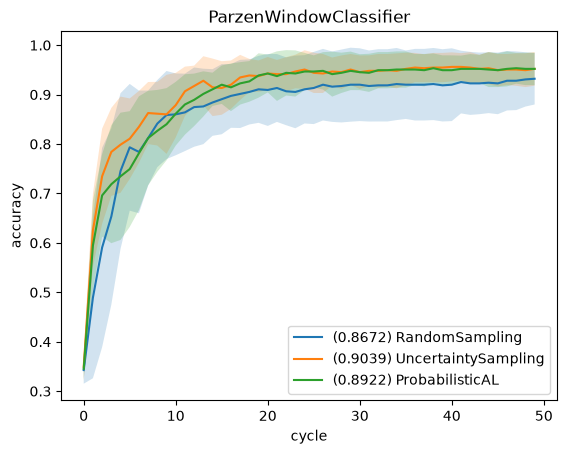

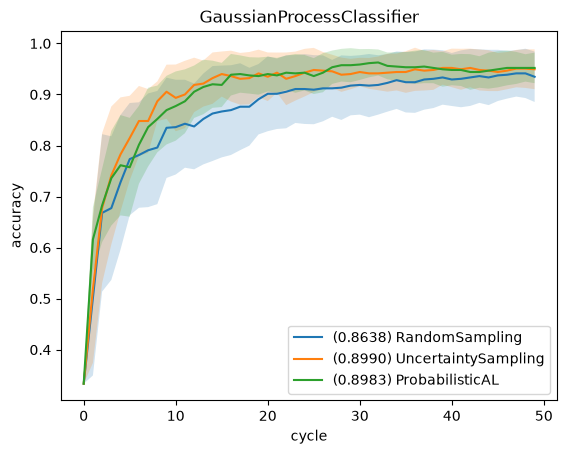

In [8]:
for clf_name in classifier_names:
    for qs_name in query_strategy_names:
        key = (clf_name, qs_name)
        result = results[key]
        reshaped_result = result.reshape((-1, n_cycles))
        errorbar_mean = np.mean(reshaped_result, axis=0)
        errorbar_std = np.std(reshaped_result, axis=0)
        label = f"({np.mean(errorbar_mean):.4f}) {qs_name}"
        plt.plot(np.arange(n_cycles), errorbar_mean, label=label)
        plt.fill_between(np.arange(n_cycles), errorbar_mean-errorbar_std, errorbar_mean+errorbar_std, alpha=0.2)
    plt.title(clf_name)
    plt.legend(loc='lower right')
    plt.xlabel('cycle')
    plt.ylabel('accuracy')
    plt.show()